In [3]:
import subprocess
import sys
import traceback

#pip install pandasql
LIBRARIES = {
    "numpy" : "numpy",
    "pandas" : "pandas",
    "sklearn" : "scikit-learn",
    "matplotlib" : "matplotlib",
    "pandasql" : "pandasql",
    "sqlite3" : "sqlite3",
    "statsmodels" : "statsmodels",
    "math" : "math",
    "scipy" : "stats"
    
}

missing_packages = []

for module, package in LIBRARIES.items():
    try:
        __import__(module)
    except ImportError:
        missing_packages.append(package)

if missing_packages:
    print(f"Missing packages detected: {missing_packages}. Installing...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
        print("All packages installed successfully!")
    except subprocess.CalledProcessError:
        _, _, tb = sys.exc_info()
        traceback.print_tb(tb)

Missing packages detected: ['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'pandasql', 'statsmodels', 'stats']. Installing...
  Using cached numpy-2.5.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scikit_learn-1.9.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached matplotlib-3.11.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached pandasql-0.7.3.tar.gz (26 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requiremen

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandasql import sqldf
import sqlite3
from sklearn import linear_model
import statsmodels.api as sm
import math
from scipy import stats

Matplotlib is building the font cache; this may take a moment.


In [6]:
# Loading in S&P1500 stock factors dataframe
merged_df = pd.read_sas('merged_df.sas7bdat', encoding='latin-1')
merged_df

,permno,yyyymm,monthid,ticker,conm,gvkey,cusip,naics,gsubind,IM,...,ret_f3,ret_f4,ret_f5,ret_f6,ret_f7,ret_f8,ret_f9,ret_f10,ret_f11,ret_f12
0,10026.0,198601.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.070588,0.406593,-0.156250,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385
1,10026.0,198602.0,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.406593,-0.156250,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746
2,10026.0,198603.0,75.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,-0.183465,...,-0.156250,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769
3,10026.0,198604.0,76.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,0.636488,...,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769,-0.119403
4,10026.0,198605.0,77.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,NaN,...,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769,-0.119403,-0.042373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440715,93429.0,201908.0,476.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.035693,0.009251,0.026833,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425
440716,93429.0,201909.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009251,0.026833,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122
440717,93429.0,201910.0,478.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.026833,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122,-0.073513
440718,93429.0,201911.0,479.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122,-0.073513,0.128552


In [7]:
# Note that there are entries with existing permno but missing gvkeys and tickers.
len(merged_df.permno.unique())

1497

In [8]:
# To center monthid on Jan 2000 so it is less confusing
merged_df.monthid = merged_df.monthid - 241
merged_df[['yyyymm', 'monthid']]

,yyyymm,monthid
0,198601.0,-168.0
1,198602.0,-167.0
2,198603.0,-166.0
3,198604.0,-165.0
4,198605.0,-164.0
...,...,...
440715,201908.0,235.0
440716,201909.0,236.0
440717,201910.0,237.0
440718,201911.0,238.0


In [9]:
# To filter for stocks meeting price and market cap for Part 2 at the beginning of each year
filtered_merged_df = merged_df
filtered_merged_df['yearmonthid'] = merged_df.monthid - merged_df.monthid % 12

In [10]:
year_groups = filtered_merged_df.groupby(['permno', 'yearmonthid'])

liquid = {'permno' : [], 'yearmonthid' : [], 'isLiquid' : []}

for name, group in year_groups :
  liquid['permno'].append(group.permno.iloc[0])
  liquid['yearmonthid'].append(group.yearmonthid.iloc[0])
  liquid['isLiquid'].append((group.PRC.iloc[0] > 5) & ((group.PRC.iloc[0] * group.SHROUT.iloc[0]) >= 100000))

# Created new column isLiquid which is True only if stock PRC > 5 and >= 100M market cap on Jan of each year.
isLiquid = pd.DataFrame(liquid)
filtered_merged_df = pd.merge(filtered_merged_df, isLiquid, on=['permno', 'yearmonthid'])
filtered_merged_df

,permno,yyyymm,monthid,ticker,conm,gvkey,cusip,naics,gsubind,IM,...,ret_f5,ret_f6,ret_f7,ret_f8,ret_f9,ret_f10,ret_f11,ret_f12,yearmonthid,isLiquid
0,10026.0,198601.0,-168.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.156250,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,-168.0,False
1,10026.0,198602.0,-167.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.375000,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,-168.0,False
2,10026.0,198603.0,-166.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,-0.183465,...,-0.066667,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769,-168.0,False
3,10026.0,198604.0,-165.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,0.636488,...,-0.166667,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769,-0.119403,-168.0,False
4,10026.0,198605.0,-164.0,JJSF,J & J SNACK FOODS CORP,012825,466032109,311812,30202030,NaN,...,0.114286,0.051282,-0.048780,0.615385,0.031746,0.030769,-0.119403,-0.042373,-168.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440715,93429.0,201908.0,235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.026833,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,228.0,True
440716,93429.0,201909.0,236.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.071904,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122,228.0,True
440717,93429.0,201910.0,237.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.217105,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122,-0.073513,228.0,True
440718,93429.0,201911.0,238.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.113501,0.074864,-0.123802,-0.059820,0.051425,-0.044122,-0.073513,0.128552,228.0,True


In [11]:
# Code to test whether isLiquid is correctly tracking stock price and cap requirements
filtered_merged_df.loc[filtered_merged_df.permno == 10026.0][['yyyymm', 'PRC', 'SHROUT', 'isLiquid']]

,yyyymm,PRC,SHROUT,isLiquid
0,198601.0,NaN,NaN,False
1,198602.0,18.750000,1945.0,False
2,198603.0,21.250000,1945.0,False
3,198604.0,22.750000,1945.0,False
4,198605.0,32.000000,1945.0,False
...,...,...,...,...
403,201908.0,193.059998,18841.0,True
404,201909.0,192.000000,18895.0,True
405,201910.0,190.759995,18895.0,True
406,201911.0,185.000000,18899.0,True


In [12]:
# Step 4: Derive Factors
## Read in 1986-2019 data for chosen factors from WRDS (factor signals & financial ratio data tables used)
f1_df = pd.read_sas('momentum12.sas7bdat', encoding='latin-1')
f2_df = pd.read_sas('ITOA.sas7bdat', encoding='latin-1')
f3_df = pd.read_sas('DIV_P.sas7bdat', encoding='latin-1')
# f4_df = pd.read_sas('BtM.sas7bdat', encoding='latin-1')
# f5_df = pd.read_sas('REVSUP.sas7bdat', encoding='latin-1')
# f6_df = pd.read_sas('momentum.sas7bdat', encoding='latin-1')
f7_df = pd.read_sas('AccrualVol.sas7bdat', encoding='latin-1')
f8_df = pd.read_sas('beta.sas7bdat', encoding='latin-1')
# f9_df = pd.read_sas('ivol.sas7bdat', encoding='latin-1')
f10_df = pd.read_sas('FCF.sas7bdat', encoding='latin-1')
f11_df = pd.read_sas('CFVol.sas7bdat', encoding='latin-1')
# f12_df = pd.read_sas('trend_factor.sas7bdat', encoding='latin-1')
f13_df = pd.read_sas('SG.sas7bdat', encoding='latin-1')
f14_df = pd.read_sas('EV_EBITDA.sas7bdat', encoding='latin-1')
f15_df = pd.read_sas('AbsAccrual.sas7bdat', encoding='latin-1')
f16_df = pd.read_sas('CASHPROD.sas7bdat', encoding='latin-1')
# f17_df = pd.read_sas('REHOLDING.sas7bdat', encoding='latin-1')
f18_df = pd.read_sas('RD_P.sas7bdat', encoding='latin-1')
f19_df = pd.read_sas('momaccel.sas7bdat', encoding='latin-1')
# f20_df = pd.read_sas('FCF_P.sas7bdat', encoding='latin-1')
#f21_df = pd.read_sas('NOA.sas7bdat', encoding='latin-1')

ratio_factors = pd.read_csv('FinRatios.csv')
ratio_factors1 = pd.read_csv('FinRatios1.csv')
ratio_factors2 = pd.read_csv('FinRatios2.csv')
ratio_factors = pd.concat([ratio_factors, ratio_factors1, ratio_factors2], ignore_index=True)

In [13]:
## Merge our factors from WRDS main signal database into our main df
WRDS_factors = [f1_df, f2_df, f3_df, f7_df, f8_df,
               f10_df, f11_df, f13_df, f14_df, f15_df, f16_df, f18_df, f19_df]
for i in WRDS_factors:
    i['monthid'] = (i['date'].dt.year - 2000) * 12 + i['date'].dt.month - 1
    filtered_merged_df = filtered_merged_df.merge(i, how='left', on=['permno', 'monthid'], suffixes=('main', 'factor')).drop(columns=['fdate', 'signal', 'date'])


In [14]:
## Merge our factors from WRDS financial ratios into the main df
ratio_factors['monthid'] = (pd.to_datetime(ratio_factors['public_date']).dt.year - 2000) * 12 + pd.to_datetime(ratio_factors['public_date']).dt.month - 1
filtered_merged_df = filtered_merged_df.merge(ratio_factors, how='left', on =['permno', 'monthid'], suffixes=('main', 'finRatios'))

In [15]:
## Use the 12-month momentum factor to and past period returns to derive the 12_1-month momentum factor
filtered_merged_df = filtered_merged_df[['permno', 'yyyymm', 'monthid', 'ticker', 'momentum12', 'ITOA', 'DIV_P', 'AccrualVol', 'beta', 'FCF', 'CFVol', 'SG', 'EV_EBITDA', 'AbsAccrual', 'CASHPROD', 'RD_P', 'momaccel', 'sue_NI', 'BM', 'EP', 'Cto', 'tail_2y', 'dp', 'aftret_invcapx', 'PRC', 'VOL', 'RET', 'SHROUT', 'ret_f1', 'ret_f2', 'ret_f3', 'ret_f4', 'ret_f5', 'ret_f6', 'ret_f7', 'ret_f8', 'ret_f9', 'ret_f10', 'ret_f11', 'ret_f12']]
filtered_merged_df = filtered_merged_df.sort_values(by=['permno', 'monthid']).reset_index(drop=True)

## We will need time t-1 returns
filtered_merged_df['ret_f-1'] = filtered_merged_df.groupby('permno')['RET'].shift(1)

twelve_one_moms = [np.nan]
for i in range(0, len(filtered_merged_df.permno)):
    if i < 1:
        continue
    elif pd.isna(filtered_merged_df.loc[i, 'momentum12']) or pd.isna(filtered_merged_df.loc[i, 'ret_f-1']):
        twelve_one_moms.append(np.nan)
    else:
        twelve_one_moms.append(((filtered_merged_df.loc[i, 'momentum12'] + 1) / (filtered_merged_df.loc[i, 'ret_f-1'] + 1)) - 1)
filtered_merged_df['momentum12_1'] = twelve_one_moms
filtered_merged_df = filtered_merged_df.drop(columns=['momentum12'])

In [16]:
# Step 5: Data Filtering
filtered_merged_df_factors = filtered_merged_df.copy()
filtered_merged_df_factors = filtered_merged_df_factors.dropna()

# Winsorize factors
winsorize = ['momentum12_1', 'ITOA', 'DIV_P', 'AccrualVol', 'beta', 'FCF', 'CFVol', 'SG', 'EV_EBITDA', 'AbsAccrual', 'CASHPROD', 'RD_P', 'momaccel', 'sue_NI', 'BM', 'EP', 'Cto', 'tail_2y', 'dp', 'aftret_invcapx'] # all our factors
std_comparison = pd.DataFrame(columns=['Original', 'Winsorized'])

for var in winsorize:
    new_var = var + '_winsorized'
    filtered_merged_df_factors[new_var] = filtered_merged_df_factors.groupby('monthid')[var].transform(
        lambda x: x.clip(lower=x.quantile(0.01, interpolation="linear"), upper=x.quantile(0.99, interpolation="linear"))
    )
    std_comparison.loc[var] = [filtered_merged_df_factors[var].std(), filtered_merged_df_factors[new_var].std()]

print("Std before and after winsorization:")
print(round(std_comparison, 4))

# Create z-score standardized versions
winsorized_cols = [col for col in filtered_merged_df_factors.columns if '_winsorized' in col]


for var in winsorized_cols:
    new_var = var
    z_col = var + '_z'
    filtered_merged_df_factors[z_col] = filtered_merged_df_factors.groupby('monthid')[new_var].transform(
        lambda x: (x - x.mean()) / x.std()
    )
filtered_merged_df_factors

Std before and after winsorization:
                Original  Winsorized
momentum12_1      0.4436      0.4181
ITOA              0.1239      0.1067
DIV_P             0.0274      0.0187
AccrualVol        0.0475      0.0402
beta              0.5630      0.5537
FCF               0.0815      0.0736
CFVol             0.0665      0.0425
SG                0.6492      0.4313
EV_EBITDA        13.2112      7.9517
AbsAccrual        0.0597      0.0528
CASHPROD         58.1139     51.5704
RD_P              0.0218      0.0157
momaccel          0.3612      0.3446
sue_NI            1.4137      1.4082
BM                0.4151      0.3618
EP                0.1855      0.1084
Cto               0.2016      0.1999
tail_2y           0.4447      0.4405
dp                0.0200      0.0179
aftret_invcapx    5.8659      0.1047


,permno,yyyymm,monthid,ticker,ITOA,DIV_P,AccrualVol,beta,FCF,CFVol,...,CASHPROD_winsorized_z,RD_P_winsorized_z,momaccel_winsorized_z,sue_NI_winsorized_z,BM_winsorized_z,EP_winsorized_z,Cto_winsorized_z,tail_2y_winsorized_z,dp_winsorized_z,aftret_invcapx_winsorized_z
34,10026.0,198811.0,-134.0,JJSF,-0.231545,0.000000,-0.026567,-0.933396,-0.026491,-0.019266,...,-0.255326,-0.148909,-0.882621,1.172531,-0.891247,-0.372947,0.032877,-0.298899,-1.023401,0.135380
35,10026.0,198812.0,-133.0,JJSF,-0.231545,0.000000,-0.026567,-0.941226,-0.026491,-0.019266,...,-0.229856,-0.180653,0.450533,1.612454,-0.912334,-0.268586,0.129805,-0.354088,-1.003459,0.138612
36,10026.0,198901.0,-132.0,JJSF,-0.231545,0.000000,-0.026567,-0.559266,-0.026491,-0.019266,...,-0.247001,-0.193805,-0.721789,1.649814,-0.924780,-0.261827,0.141870,-0.320917,-1.033964,0.164434
37,10026.0,198902.0,-131.0,JJSF,-0.294626,0.000000,-0.025061,-0.638775,-0.033348,-0.018244,...,-0.243922,-0.559513,-0.703724,1.536945,-0.820738,-0.252543,-0.067329,-0.346379,-1.081198,-0.030280
38,10026.0,198903.0,-130.0,JJSF,-0.294626,0.000000,-0.025061,-0.575528,-0.033348,-0.018244,...,-0.237831,-0.538956,-1.439428,0.350010,-0.827079,-0.277839,-0.313899,-0.397638,-1.105963,-0.030461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440697,93429.0,201802.0,217.0,CBOE,-0.113824,0.009355,-0.065708,-1.140011,0.041552,-0.169489,...,-1.471444,-0.520901,-0.699756,0.580347,-0.536914,-0.500498,-0.720225,-0.490548,-0.338726,4.269224
440698,93429.0,201803.0,218.0,CBOE,-0.113824,0.009196,-0.065708,-1.288860,0.041552,-0.169489,...,-1.438528,-0.522465,-1.147549,1.385908,-0.581906,-0.240776,-0.696947,-0.556422,-0.268005,4.236263
440699,93429.0,201804.0,219.0,CBOE,-0.113824,0.009832,-0.065708,-1.222922,0.041552,-0.169489,...,-1.451668,-0.516938,-1.103703,1.331656,-0.582428,-0.206660,-0.695489,1.959551,-0.248787,4.219986
440700,93429.0,201805.0,220.0,CBOE,0.007137,0.010971,-0.069335,-1.221257,0.074659,-0.204043,...,-0.487303,-0.408461,-1.109960,1.482825,-0.636494,-0.215462,-0.607829,-0.621174,-0.256788,0.141993


In [17]:
# Step 6 - Fama-MacBeth cross-sectional regressions

months = sorted(filtered_merged_df_factors['monthid'].unique())

# Pick the 75% point for seeing what the training cutoff should be in this case
cut_idx = int(len(months) * 0.75)  # e.g. 0.75 * 396 ≃ 297
TRAIN_CUTOFF = months[cut_idx]

print("Training sample covers monthid <=", TRAIN_CUTOFF,
      "(", cut_idx, "out of", len(months), "months )")

Training sample covers monthid <= 138.0 ( 306 out of 408 months )


In [18]:
# Define training sample
TRAIN_CUTOFF = 138.0
# copying over the table
train_df = filtered_merged_df_factors[filtered_merged_df_factors.monthid <= TRAIN_CUTOFF]

# Identify your z‑scored factor columns
factor_z_cols = [c for c in train_df.columns if c.endswith('_winsorized_z')]

# Run the monthly cross‑sectional regressions
monthly_coefs = []
for yyyymm, grp in train_df.groupby('yyyymm'):
    grp = grp.dropna(subset=['ret_f1'] + factor_z_cols)
    if len(grp) < len(factor_z_cols) + 1:
        continue
    Y = grp['ret_f1']
    X = sm.add_constant(grp[factor_z_cols])
    model = sm.OLS(Y, X, missing='drop').fit()
    # Convert the parameters Series to a dict, then inject the month, this gives month for df_fm_coefs
    row = model.params.to_dict()
    row['yyyymm'] = yyyymm
    monthly_coefs.append(row)

df_fm_coefs = pd.DataFrame(monthly_coefs) \
    .set_index('yyyymm') \
    .sort_index()

# Compute averages and t‑stats
T = len(df_fm_coefs)
means  = df_fm_coefs.mean()
stds   = df_fm_coefs.std()
se     = stds / np.sqrt(T)
tstats = means / se

fm_summary = pd.DataFrame({
    'avg_premia': means,
    'std_err':    se,
    't_stat':     tstats,
    'n_months':   T
}).round(4)

print("Fama–MacBeth Results on Training Sample (months ≤ 138):")
fm_summary

Fama–MacBeth Results on Training Sample (months ≤ 138):


,avg_premia,std_err,t_stat,n_months
const,0.0157,0.0029,5.3265,307
momentum12_1_winsorized_z,0.0022,0.0011,1.9595,307
ITOA_winsorized_z,0.0002,0.0005,0.3606,307
DIV_P_winsorized_z,0.0019,0.0010,1.9171,307
AccrualVol_winsorized_z,0.0001,0.0006,0.1642,307
beta_winsorized_z,0.0003,0.0010,0.2789,307
FCF_winsorized_z,0.0014,0.0004,3.2659,307
CFVol_winsorized_z,-0.0018,0.0007,-2.6477,307
SG_winsorized_z,0.0011,0.0004,3.1345,307
EV_EBITDA_winsorized_z,0.0019,0.0005,4.0156,307


In [19]:
# Gives the table with the coefs and winsorized z of all the facotrs for each entry
df_fm_coefs.head()

,const,momentum12_1_winsorized_z,ITOA_winsorized_z,DIV_P_winsorized_z,AccrualVol_winsorized_z,beta_winsorized_z,FCF_winsorized_z,CFVol_winsorized_z,SG_winsorized_z,EV_EBITDA_winsorized_z,...,CASHPROD_winsorized_z,RD_P_winsorized_z,momaccel_winsorized_z,sue_NI_winsorized_z,BM_winsorized_z,EP_winsorized_z,Cto_winsorized_z,tail_2y_winsorized_z,dp_winsorized_z,aftret_invcapx_winsorized_z
yyyymm,,,,,,,,,,,,,,,,,,,,,
198601.0,0.078624,0.001804,-0.002249,-0.002013,-0.001639,-0.004451,0.007985,0.001205,-0.001196,-0.002020,...,0.002289,0.003381,0.009806,0.002196,-0.021979,0.027906,-0.000938,0.006347,-0.012417,-0.008969
198602.0,0.064316,0.013623,0.011398,-0.000504,0.000756,-0.002458,-0.017883,-0.007505,0.005334,-0.001895,...,0.009488,-0.013849,0.021475,0.016983,0.015958,0.007052,0.009958,0.001336,-0.001551,0.032611
198603.0,0.010592,-0.038421,-0.016668,0.010836,0.017513,0.003270,0.013039,-0.025742,0.005910,0.003096,...,-0.001419,-0.002894,-0.044647,-0.004330,-0.014249,0.004098,-0.006327,0.008956,-0.021489,-0.019945
198604.0,0.044833,0.020995,-0.014726,0.012761,-0.009481,0.008929,0.000989,0.020771,0.004430,0.011270,...,-0.001257,-0.004127,0.010824,0.012815,0.005803,-0.020087,0.004897,0.004873,-0.006657,0.006258
198605.0,0.006860,0.011571,-0.000929,-0.007682,0.017990,0.018420,-0.009477,-0.015929,0.003152,0.006345,...,-0.001834,-0.008990,0.005874,0.016042,-0.009783,-0.006170,0.001011,0.002342,0.027618,0.013292


Re-Training withe the amount

In [20]:
# step 8 - choosing factors

t_threshold = 1.5    # <<< raise/lower this to be more/less strict

# Identify factors meeting the threshold
# Drop the intercept—only look at real factors
raw_factors = fm_summary.index.drop('const')
mask = fm_summary.loc[raw_factors, 't_stat'].abs() >= t_threshold
factors_to_keep = raw_factors[mask].tolist()

print("✔︎ Factors with |t| ≥", t_threshold, ":")
for f in factors_to_keep:
    val = fm_summary.loc[f, ['avg_premia','t_stat']]
    print(f"   • {f:30s}  avg_premia={val.avg_premia:.4f}, t_stat={val.t_stat:.2f}")

✔︎ Factors with |t| ≥ 1.5 :
   • momentum12_1_winsorized_z       avg_premia=0.0022, t_stat=1.96
   • DIV_P_winsorized_z              avg_premia=0.0019, t_stat=1.92
   • FCF_winsorized_z                avg_premia=0.0014, t_stat=3.27
   • CFVol_winsorized_z              avg_premia=-0.0018, t_stat=-2.65
   • SG_winsorized_z                 avg_premia=0.0011, t_stat=3.13
   • EV_EBITDA_winsorized_z          avg_premia=0.0019, t_stat=4.02
   • AbsAccrual_winsorized_z         avg_premia=-0.0011, t_stat=-2.57
   • RD_P_winsorized_z               avg_premia=0.0028, t_stat=5.51
   • sue_NI_winsorized_z             avg_premia=0.0007, t_stat=2.01
   • BM_winsorized_z                 avg_premia=0.0027, t_stat=4.18
   • EP_winsorized_z                 avg_premia=-0.0017, t_stat=-2.40
   • Cto_winsorized_z                avg_premia=0.0011, t_stat=2.22
   • tail_2y_winsorized_z            avg_premia=0.0019, t_stat=4.57
   • dp_winsorized_z                 avg_premia=-0.0023, t_stat=-2.16


In [21]:
# step 9 - ReTrain with wanted factors
TRAIN_CUTOFF = 138.0
train_df = filtered_merged_df_factors[filtered_merged_df_factors.monthid <= TRAIN_CUTOFF].copy()

# Remove 4 manually decided factors
factors_to_keep.remove("DIV_P_winsorized_z")
factors_to_keep.remove("AbsAccrual_winsorized_z")
factors_to_keep.remove("EV_EBITDA_winsorized_z")
factors_to_keep.remove("RD_P_winsorized_z")

# cleans out any rows missing the dependent or kept factors
train_df = train_df.dropna(subset=['ret_f1'] + factors_to_keep)

# Run monthly cross‐sectionals again, but only on the `factors_to_keep`
monthly_final = []
for yyyymm, grp in train_df.groupby('yyyymm'):
    grp = grp.dropna(subset=['ret_f1'] + factors_to_keep)
    if len(grp) < len(factors_to_keep) + 1:
        continue

    Y = grp['ret_f1']
    X = sm.add_constant(grp[factors_to_keep])   # intercept + kept factors
    model = sm.OLS(Y, X, missing='drop').fit()

    # store the full set of params, plus the month
    row = model.params.to_dict()
    row['yyyymm'] = yyyymm
    monthly_final.append(row)

# Build DataFrame and compute new averages & t‐stats
df_final_coefs = (
    pd.DataFrame(monthly_final)
      .set_index('yyyymm')
      .sort_index()
)

T2 = len(df_final_coefs)
means2  = df_final_coefs.mean()
stds2   = df_final_coefs.std()
se2     = stds2 / np.sqrt(T2)
t2      = means2 / se2

final_summary = pd.DataFrame({
    'avg_premia': means2,
    'std_err':    se2,
    't_stat':     t2,
    'n_months':   T2
}).round(4)

print("\n✔︎ Final Fama–MacBeth (using kept factors):")
print(final_summary.loc[factors_to_keep + ['const']])


✔︎ Final Fama–MacBeth (using kept factors):
                           avg_premia  std_err  t_stat  n_months
momentum12_1_winsorized_z      0.0013   0.0009  1.4884       307
FCF_winsorized_z               0.0017   0.0004  4.4326       307
CFVol_winsorized_z            -0.0020   0.0007 -2.9318       307
SG_winsorized_z                0.0013   0.0004  3.6008       307
sue_NI_winsorized_z            0.0005   0.0004  1.3933       307
BM_winsorized_z                0.0029   0.0006  4.6202       307
EP_winsorized_z               -0.0017   0.0007 -2.5140       307
Cto_winsorized_z               0.0012   0.0005  2.4720       307
tail_2y_winsorized_z           0.0018   0.0005  3.7668       307
dp_winsorized_z               -0.0007   0.0006 -1.0494       307
const                          0.0157   0.0029  5.3265       307


In [22]:
# step 10 - make out os sample dataframe
TRAIN_CUTOFF = 138.0

test_df = (
    filtered_merged_df_factors
    .loc[filtered_merged_df_factors.monthid > TRAIN_CUTOFF]
    .dropna(subset=['ret_f1'] + factors_to_keep)
    .reset_index(drop=True)
)

print(f"Out-of-sample covers months > {TRAIN_CUTOFF}, with {len(test_df)} rows.")

Out-of-sample covers months > 138.0, with 104632 rows.


In [23]:
# This will basically pull in the final in-sample premia & t-stats
#    (computed in Step 9, in final_summary)
premia = final_summary['avg_premia'].to_dict()
tstats = final_summary['t_stat']  .to_dict()

# Predicted‐return approach
# Vectorized formula: α + Σ β_j · F_j
test_df['pred_ret'] = premia['const']
for f in factors_to_keep:
    test_df['pred_ret'] += premia[f] * test_df[f]

# 3B) T-stat‐weighted score approach
# Score = Σ (z_score_f × t_stat_f)
test_df['score'] = 0.0
for f in factors_to_keep:
    test_df['score'] += tstats[f] * test_df[f]

In [24]:
# Function that ranks them into deciles within each month
def assign_decile(x, col):
    # pd.qcut needs at least as many unique values as bins, should be fine
    return pd.qcut(x[col], 10, labels=False, duplicates='drop') + 1

test_df['decile_pred'] = (
    test_df
    .groupby('yyyymm', group_keys=False)
    .apply(lambda g: assign_decile(g, 'pred_ret'))
) # tdoes it for ret

test_df['decile_score'] = (
    test_df
    .groupby('yyyymm', group_keys=False)
    .apply(lambda g: assign_decile(g, 'score'))
) # does it for the score values

# table outputs
condensed_full_df = test_df[['monthid', 'yyyymm','permno','pred_ret','decile_pred','score','decile_score', 'ret_f1']]

In [25]:
# Step 12a: Build our decile-based portfolios for each month

def build_decile_portfolio(method, df):
    # Which scoring method are we using
    scoring_string = ""
    if (method == "decile_pred"):
       scoring_string = "pred_ret"
    elif (method == "decile_score"):
        scoring_string = "score"

    # For each month, we group together the stocks included in each decile portfolio
    df["monthid" + method] = df["monthid"].astype(str) + df[method].astype(str)
    model_deciles = df.groupby(["monthid" + method])
    decile_dict = {'monthid':[], method:[], 'freq':[], 'return':[], scoring_string:[]}

    # Now we populate and build a dataframe of our 10 decile portfolios
    for name, group in model_deciles:
        decile_dict['monthid'].append(group['monthid'].iloc[0])
        decile_dict[method].append(group[method].iloc[0])
        decile_dict['freq'].append(group.shape[0])
        decile_dict['return'].append(group['ret_f1'].mean())
        decile_dict[scoring_string].append(group[scoring_string].mean())
    deciles_df = pd.DataFrame(decile_dict)
    deciles_df_sorted = deciles_df.sort_values(["monthid", method])
    return deciles_df_sorted
pred_deciles = build_decile_portfolio('decile_pred', condensed_full_df)
score_deciles = build_decile_portfolio('decile_score', condensed_full_df)
pred_deciles

,monthid,decile_pred,freq,return,pred_ret
0,139.0,1,98,-0.069418,0.008045
2,139.0,2,98,-0.089125,0.010696
3,139.0,3,97,-0.083066,0.011998
4,139.0,4,98,-0.100558,0.013249
5,139.0,5,97,-0.089836,0.014413
...,...,...,...,...,...
1006,239.0,6,115,-0.031279,0.015744
1007,239.0,7,115,-0.054981,0.016856
1008,239.0,8,116,-0.037244,0.018421
1009,239.0,9,115,-0.030546,0.020590


In [26]:
# Step 11/12b/13 Compute the two 10% decile extreme portfolios, using equal-weighting
# Simultaneously we build the hedge portfolio, which simply has the return difference of our long and short portfolios
def min_max_portfolios(method, df):
    # Construct, 10% long, 10% short and hedge portfolios
    shortPortfolio = df.loc[df[method]==1]
    longPortfolio = df.loc[df[method]==10]
    hedgePortfolio = pd.merge(shortPortfolio,longPortfolio,how='inner', on=["monthid"])
    hedgePortfolio['hedge_ret'] = hedgePortfolio["return_y"]-hedgePortfolio["return_x"]
    hedgeSorted = hedgePortfolio.sort_values(["monthid"])
    # Merge check - t_tests should be the same for each function call
    print(stats.ttest_ind(longPortfolio['return'], shortPortfolio['return']))
    print(stats.ttest_ind(hedgeSorted['return_y'], hedgeSorted['return_x']))
    print("BREAK")
    return [longPortfolio, shortPortfolio, hedgeSorted]
pred_dfs = min_max_portfolios('decile_pred', pred_deciles)
score_dfs = min_max_portfolios('decile_score', score_deciles)
pred_dfs[2] # Hedge df using Method 1 for scoring


TtestResult(statistic=np.float64(1.2517011680923358), pvalue=np.float64(0.2121407392513378), df=np.float64(200.0))
TtestResult(statistic=np.float64(1.2517011680923358), pvalue=np.float64(0.2121407392513378), df=np.float64(200.0))
BREAK
TtestResult(statistic=np.float64(1.0392604473035867), pvalue=np.float64(0.299938386533412), df=np.float64(200.0))
TtestResult(statistic=np.float64(1.0392604473035867), pvalue=np.float64(0.299938386533412), df=np.float64(200.0))
BREAK


,monthid,decile_pred_x,freq_x,return_x,pred_ret_x,decile_pred_y,freq_y,return_y,pred_ret_y,hedge_ret
0,139.0,1,98,-0.069418,0.008045,10,98,-0.123394,0.026427,-0.053976
1,140.0,1,99,0.100830,0.007947,10,99,0.190103,0.026383,0.089273
2,141.0,1,99,0.006495,0.007772,10,99,-0.023686,0.026065,-0.030180
3,142.0,1,98,0.021007,0.008354,10,98,0.018279,0.025758,-0.002728
4,143.0,1,97,0.032834,0.007978,10,97,0.123072,0.026301,0.090238
...,...,...,...,...,...,...,...,...,...,...
96,235.0,1,116,0.064242,0.008732,10,116,0.038327,0.026125,-0.025916
97,236.0,1,117,0.007630,0.008766,10,117,0.018061,0.025756,0.010431
98,237.0,1,117,0.030794,0.008881,10,117,0.051133,0.025861,0.020338
99,238.0,1,116,0.033682,0.008307,10,116,0.061835,0.026518,0.028153


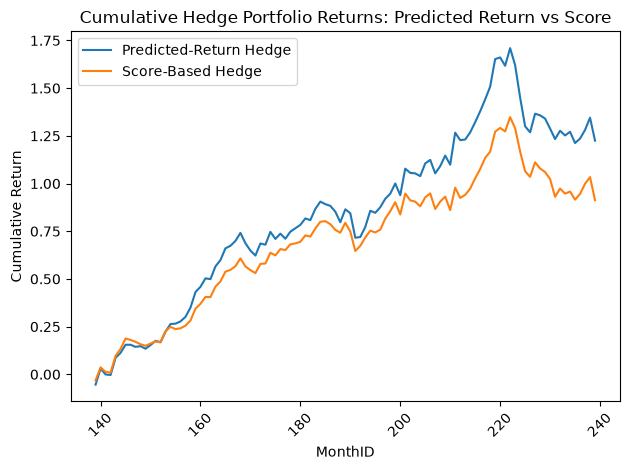

In [27]:
# combine DataFrame for the two types of methods
df_pred = pred_dfs[2][['monthid', 'hedge_ret']].rename(columns={'hedge_ret':'pred_hedge_ret'})
df_score = score_dfs[2][['monthid', 'hedge_ret']].rename(columns={'hedge_ret':'score_hedge_ret'})
df_combined = pd.merge(df_pred, df_score, on='monthid')
df_combined = df_combined.sort_values('monthid').reset_index(drop=True)

# Compute cumulative returns
df_combined['cumret_pred'] = (1 + df_combined['pred_hedge_ret']).cumprod() - 1
df_combined['cumret_score'] = (1 + df_combined['score_hedge_ret']).cumprod() - 1

# Plotting
plt.figure()
plt.plot(df_combined['monthid'], df_combined['cumret_pred'], label='Predicted-Return Hedge')
plt.plot(df_combined['monthid'], df_combined['cumret_score'], label='Score-Based Hedge')
plt.xlabel('MonthID')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Hedge Portfolio Returns: Predicted Return vs Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()